In [2]:
# Q1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
# Q2
df = pd.read_csv("mpg.csv")

df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [4]:
# Q3
print(df.isnull().sum())

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

print("Duplicate rows before removing:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removing:", df.duplicated().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
mpg             0.000000
cylinders       0.000000
displacement    0.000000
horsepower      1.507538
weight          0.000000
acceleration    0.000000
model_year      0.000000
origin          0.000000
name            0.000000
dtype: float64
Duplicate rows before removing: 0
Duplicate rows after removing: 0


In [5]:
# Q4
print(df.describe())

print("Minimum mpg:", df["mpg"].min())
print("Maximum mpg:", df["mpg"].max())
print("Mean mpg:", df["mpg"].mean())
print("Median mpg:", df["mpg"].median())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.304020  2970.424623   
std      7.815984    1.701004    104.269838   38.222625   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.568090   76.010050  
std        2.757689    3.697627  
min        8.000000   70.000000  
25%       13.825000   73.000000  
50%       15.500000   76.000000  
75%       17.175000   79.000000  
max       24.800000   82.000000  
Minimum mpg: 9.0
Maximum mpg: 46.6
Mean mpg: 

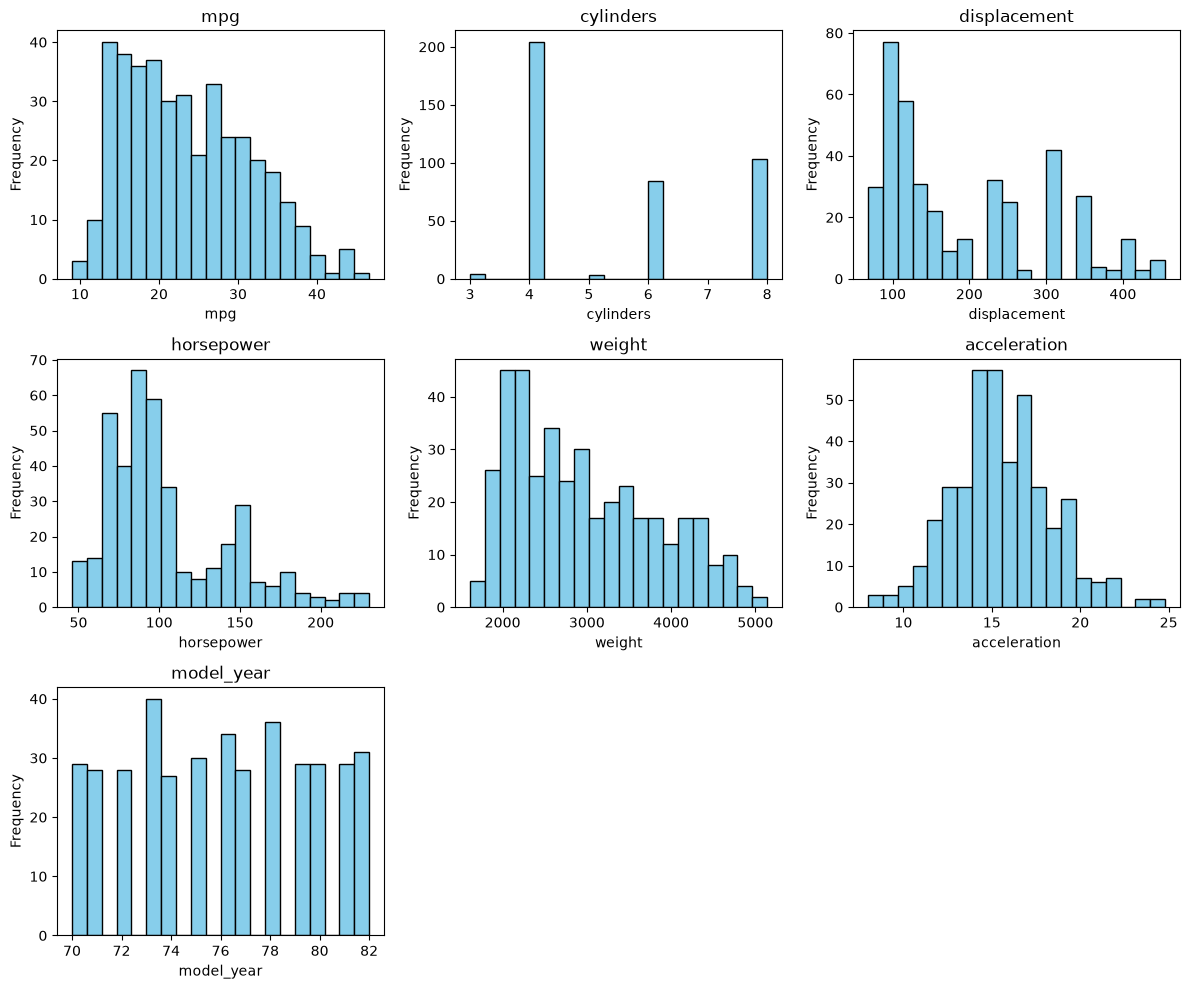

In [6]:
# Q5
numeric_columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i in range(len(numeric_columns)):
    col = numeric_columns[i]
    axes[i].hist(df[col], bins=20, color="skyblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

axes[7].axis("off")
axes[8].axis("off")

plt.tight_layout()
plt.show()

Categorical columns identified: ['origin']


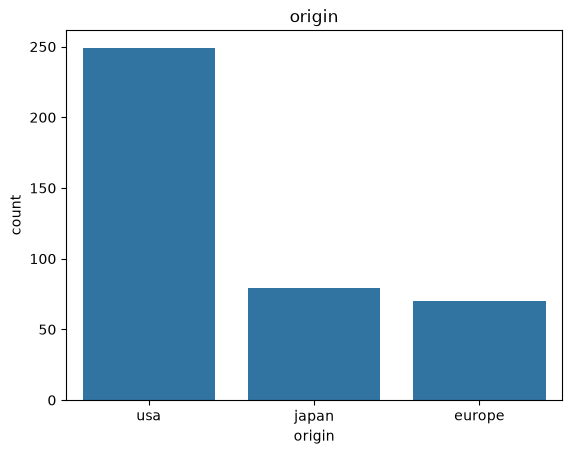

In [7]:
# Q6
categorical_columns = ["origin"]

print("Categorical columns identified:", categorical_columns)

for col in categorical_columns:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.773453 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.841284  0.896017   
displacement -0.804203   0.950721      1.000000    0.895778  0.932824   
horsepower   -0.773453   0.841284      0.895778    1.000000  0.862442   
weight       -0.831741   0.896017      0.932824    0.862442  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.686590 -0.417457   
model_year    0.579267  -0.348746     -0.370164   -0.413733 -0.306564   

              acceleration  model_year  
mpg               0.420289    0.579267  
cylinders        -0.505419   -0.348746  
displacement     -0.543684   -0.370164  
horsepower       -0.686590   -0.413733  
weight           -0.417457   -0.306564  
acceleration      1.000000    0.288137  
model_year        0.288137    1.000000  


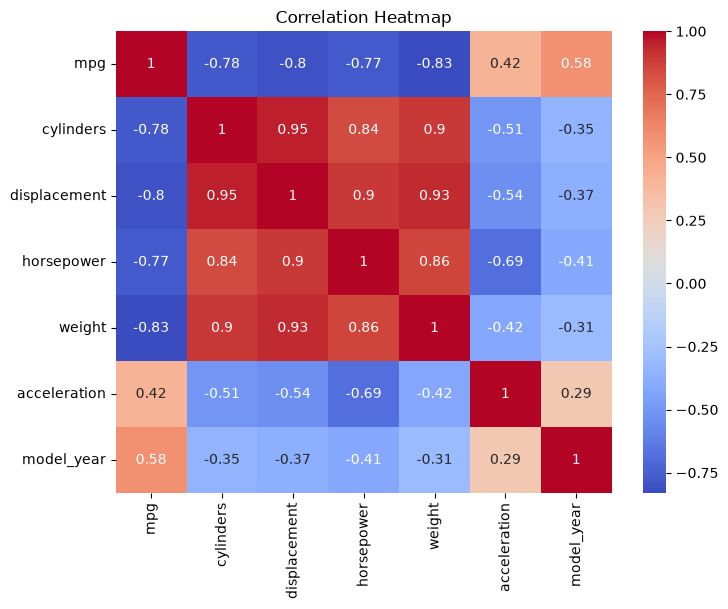

In [8]:
# Q7
numeric_df = df[["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]]

correlation_matrix = numeric_df.corr()
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Q8
X = df.drop(["mpg", "name"], axis=1)
y = df["mpg"]

print("Independent Features (X):")
print(X.columns.tolist())
print("Dependent Feature (y): mpg")

Independent Features (X):
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
Dependent Feature (y): mpg


In [10]:
# Q9
print("Before encoding")
print(X["origin"].head())

X_encoded = pd.get_dummies(X, columns=["origin"], drop_first=True)

print("After encoding")
print(X_encoded.head())

Before encoding
0    usa
1    usa
2    usa
3    usa
4    usa
Name: origin, dtype: str
After encoding
   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0          8         307.0       130.0    3504          12.0          70   
1          8         350.0       165.0    3693          11.5          70   
2          8         318.0       150.0    3436          11.0          70   
3          8         304.0       150.0    3433          12.0          70   
4          8         302.0       140.0    3449          10.5          70   

   origin_japan  origin_usa  
0         False        True  
1         False        True  
2         False        True  
3         False        True  
4         False        True  


In [11]:
# Q10
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)
print(X_scaled_df.head())

   cylinders  displacement  horsepower    weight  acceleration  model_year  \
0   1.498191      1.090604    0.673118  0.630870     -1.295498   -1.627426   
1   1.498191      1.503514    1.589958  0.854333     -1.477038   -1.627426   
2   1.498191      1.196232    1.197027  0.550470     -1.658577   -1.627426   
3   1.498191      1.061796    1.197027  0.546923     -1.295498   -1.627426   
4   1.498191      1.042591    0.935072  0.565841     -1.840117   -1.627426   

   origin_japan  origin_usa  
0     -0.497643    0.773559  
1     -0.497643    0.773559  
2     -0.497643    0.773559  
3     -0.497643    0.773559  
4     -0.497643    0.773559  
